## EJERCICIO PRACTICO CLASE 3

GRUPO 4 - INTEGRANTES
- DARIO WLADIMIR HERRERA CHÁVEZ
- SANTIAGO PAUL GUALLICHICO ATI
- ROBINSON  DAMIAN CHILUISA GALLARDO


## 1. Descripcion del Trabajo
Se utiliza el dataset del Titanic, donde se cuenta con información de 891 pasajeros. Cada pasajero está descrito por variables demográficas y de viaje (clase, sexo, edad, número de familiares a bordo, tarifa pagada, puerto de embarque, entre otras). Se pretende aprender si un pasajero sobrevivió o no (Survived: 1 = sobrevivió, 0 = no sobrevivió), utilizando previamente el algoritmo PCA para reducción de dimensiones. Luego se realiza un agrupamiento (clustering) usando K-Means y Gaussian Mixture Models (GMM), comparando los clústeres obtenidos con los componentes principales de PCA y con las clases reales del dataset. En este conjunto de datos la distribución de clases es: 549 no sobrevivientes y 342 sobrevivientes.

Este trabajo se desarrolla en dos fases: la Fase I aborda la reducción de dimensiones con PCA y la clasificación supervisada (con y sin PCA); la Fase II aborda el agrupamiento no supervisado, comparando K-Means y GMM con distintos números de clústeres (K=2 y K=3).

### 1.1 Modelos de clasificación evaluados con PCA=2

Se evaluaron los siguientes algoritmos de clasificación supervisada:

- LR: Regresión Logística
- K-NN: K-Nearest Neighbors
- NB: Naive Bayes
- DT: Árbol de Decisión
- RF: Random Forest
- ANN: Red Neuronal Artificial (MLP)
- SVM: Support Vector Machine


## 2. Objetivo y alcance del trabajo
Esta práctica tiene el objetivo de realizar la predicción de la supervivencia de los pasajeros del Titanic (sobrevivió=1, no sobrevivió=0) utilizando el algoritmo de reducción de dimensiones PCA y los algoritmos de clasificación supervisada revisados anteriormente, así como realizar tareas de agrupamiento (clustering) con K-Means y GMM, evaluando ambos enfoques mediante las métricas y gráficas de rendimiento correspondientes. Al finalizar la práctica, los maestrantes podrán entender el impacto de usar PCA en el dataset, así como comparar la calidad del agrupamiento obtenido por distintos algoritmos no supervisados y distintos números de clústeres.

## 3. Desarrollo del trabajo

### 3.1 Importación de Liberias y metricas

Se realiza la importación de las librerías y métricas necesarias para el desarrollo del modelo de machine learning, incluyendo herramientas para manipulación de datos, preprocesamiento, reducción de dimensionalidad, entrenamiento de algoritmos de clasificación y evaluación del desempeño mediante diferentes métricas.

In [5]:
# =========================================
# 3.1. IMPORTACIÓN DE LIBRERÍAS Y METRICAS
# =========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# IMPORTACIÓN DE MÉTRICAS
# =========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


### 3.2 Carga del Dataset

Se realiza la carga del dataset del Titanic (titanic_train.csv). Se efectúa un preprocesamiento básico: eliminación de columnas no informativas (PassengerId, Name, Ticket, Cabin), imputación de valores nulos en Age (mediana) y Embarked (moda), y codificación de variables categóricas (Sex, Embarked) mediante Label Encoding. Posteriormente, se separan las variables independientes (X), que contienen las características del conjunto de datos, y la variable dependiente (y), que representa la clase objetivo (0 = no sobrevivió, 1 = sobrevivió), para su uso en el entrenamiento del modelo de clasificación.

In [6]:
# =========================================
# 3.2. CARGA DEL DATASET
# =========================================

df = pd.read_csv("titanic_train.csv")

# ---- Preprocesamiento básico ----
# Eliminar columnas no informativas
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Imputar valores nulos
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Codificar variables categóricas
le_sex = LabelEncoder()
df["Sex"] = le_sex.fit_transform(df["Sex"])

le_emb = LabelEncoder()
df["Embarked"] = le_emb.fit_transform(df["Embarked"])

# Separar features (X) y target (y)
X = df.drop(columns=["Survived"]).values
y = df["Survived"].values  # 0 = No sobrevivió | 1 = Sobrevivió

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Distribución de clases:", np.bincount(y))


Dimensiones de X: (891, 7)
Dimensiones de y: (891,)
Distribución de clases: [549 342]


### 3.3 Train /Test Split

Se realiza la división del dataset en conjuntos de entrenamiento y prueba utilizando train_test_split. El 80% de los datos se asigna al entrenamiento y el 20% al test, asegurando una partición estratificada según la variable objetivo (stratify=y) para mantener la proporción de clases. Además, se establece un random_state para garantizar la reproducibilidad de los resultados

In [7]:
# =========================================
# 3.3. TRAIN / TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 3.4 Escalado de Datos

Se realiza el escalado de los datos utilizando StandardScaler, con el objetivo de estandarizar las variables del conjunto de datos. Primero se ajusta el escalador con los datos de entrenamiento (fit_transform) y luego se aplica la misma transformación al conjunto de prueba (transform), garantizando que ambos queden en la misma escala para mejorar el rendimiento de los modelos de machine learning.

In [8]:
# =========================================
# 3.4. ESCALADO DE DATOS
# =========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 3.5 PCA = 2 componentes

Se aplica el análisis de componentes principales (PCA) con el objetivo de reducir la dimensionalidad de los datos a 2 componentes principales. Primero se ajusta el modelo con el conjunto de entrenamiento escalado (fit_transform) y luego se transforma el conjunto de prueba (transform), permitiendo conservar la mayor cantidad de información posible en menos variables para facilitar la visualización y el entrenamiento de los modelos.

In [9]:
# =========================================
# 3.5. PCA (2 COMPONENTES)
# =========================================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())


Varianza explicada por componente: [0.26945897 0.24260044]
Varianza explicada acumulada: 0.5120594027011032


### 3.6 Visualizacion PCA

Se realiza la visualización del conjunto de entrenamiento después de aplicar PCA con 2 componentes principales. Los datos se separan según su clase (no sobrevivió y sobrevivió) y se representan en un gráfico de dispersión, donde cada punto corresponde a una muestra proyectada en el espacio reducido. Esto permite observar de forma visual la distribución de las clases y su posible separabilidad en las dos dimensiones principales

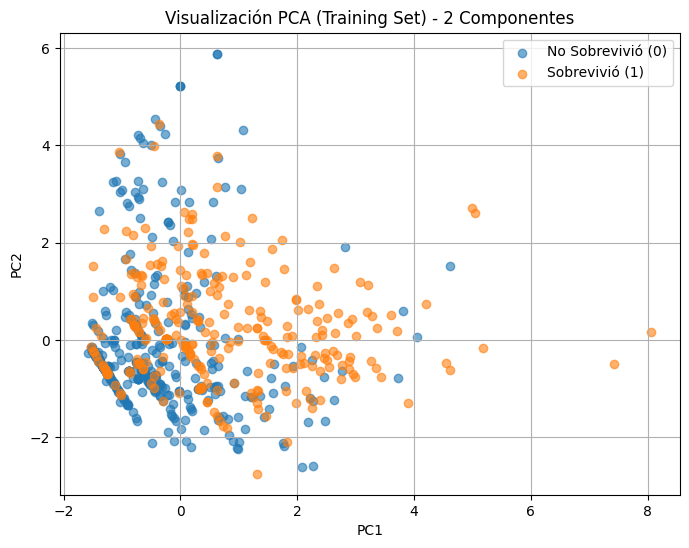

In [10]:
# =========================================
# 3.6. VISUALIZACIÓN PCA (TRAINING SET)
# =========================================

X_no_sobrevivio = X_train_pca[y_train == 0]
X_sobrevivio = X_train_pca[y_train == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_no_sobrevivio[:, 0], X_no_sobrevivio[:, 1], alpha=0.6, label="No Sobrevivió (0)")
plt.scatter(X_sobrevivio[:, 0], X_sobrevivio[:, 1], alpha=0.6, label="Sobrevivió (1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA (Training Set) - 2 Componentes")
plt.legend()
plt.grid(True)
plt.show()


### 3.7  Definicion de los Modelos

Se definen distintos modelos de clasificación supervisada que serán utilizados para el análisis del dataset. Se incluyen algoritmos como Regresión Logística, K-Nearest Neighbors, Naive Bayes, Árboles de Decisión, Random Forest, Redes Neuronales (MLP) y Support Vector Machine (SVM). Todos los modelos se almacenan en un diccionario para facilitar su entrenamiento, evaluación y comparación posterior.

In [11]:
# =========================================
# 3.7. DEFINICIÓN DE MODELOS
# =========================================

modelos = {
    "LR": LogisticRegression(max_iter=1000),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True)
}


###  3.8 Evaluacion de metricas

Se realiza el entrenamiento y evaluación de múltiples modelos de clasificación definidos previamente. Para cada modelo se ajusta el entrenamiento con los datos escalados, se realizan predicciones sobre el conjunto de prueba y, en caso de ser posible, se calculan probabilidades para obtener el área bajo la curva ROC (AUC).

Posteriormente, se calculan diferentes métricas de desempeño como accuracy, precision, recall y F1-score. Todos los resultados se almacenan en una lista y finalmente se organizan en una tabla para comparar el rendimiento de cada modelo en el conjunto de prueba.

In [12]:
# =========================================
# 3.8 MÉTRICAS PARA CADA MODELO
# =========================================

metricas = []

for nombre, modelo in modelos.items():

    # ---- Entrenar modelo ----
    modelo.fit(X_train_scaled, y_train)

    # ---- Predicciones ----
    y_pred = modelo.predict(X_test_scaled)

    # ---- Probabilidades (para ROC AUC) ----
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan  # algunos modelos no soportan predict_proba

    # ---- Métricas ----
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metricas.append([
        nombre,
        round(acc, 3),
        round(prec, 3),
        round(rec, 3),
        round(f1, 3),
        round(auc, 3) if not np.isnan(auc) else "N/A"
    ])

# =========================================
# TABLA FINAL DE MÉTRICAS
# =========================================

df_metricas = pd.DataFrame(
    metricas,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC AUC"
    ]
)

print("\nMÉTRICAS POR MODELO (TEST SET)\n")
print(df_metricas)



MÉTRICAS POR MODELO (TEST SET)

  Modelo  Accuracy  Precision  Recall  F1-score  ROC AUC
0     LR     0.799      0.780   0.667     0.719    0.852
1   K-NN     0.810      0.787   0.696     0.738    0.841
2     NB     0.782      0.727   0.696     0.711    0.833
3     DT     0.832      0.800   0.754     0.776    0.811
4     RF     0.827      0.806   0.725     0.763    0.828
5    ANN     0.782      0.759   0.638     0.693    0.853
6    SVM     0.816      0.833   0.652     0.732    0.838


### 3.9 Entrenamiento y Evaluacion

Se realiza el entrenamiento y evaluación de los modelos de clasificación tanto sin reducción de dimensionalidad como utilizando PCA con 2 componentes. Para cada modelo, se entrena primero con los datos escalados originales y luego con los datos reducidos mediante PCA, calculando la exactitud (accuracy) en ambos casos.

Además, se guardan los modelos entrenados en archivos .pkl utilizando joblib, y se registra el tamaño de cada modelo en memoria. Finalmente, los resultados de rendimiento y tamaño de los modelos se almacenan en una lista para su posterior análisis y comparación.

In [13]:
# =========================================
# 3.9. ENTRENAMIENTO Y EVALUACIÓN
# =========================================

resultados = []
os.makedirs("modelos_titanic", exist_ok=True)

for nombre, modelo in modelos.items():

    # ----- SIN PCA -----
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    archivo = f"modelos_titanic/{nombre}_sin_pca.pkl"
    joblib.dump(modelo, archivo)
    size_kb = os.path.getsize(archivo) / 1024

    # ----- CON PCA (2) -----
    modelo_pca = modelo.__class__(**modelo.get_params())
    modelo_pca.fit(X_train_pca, y_train)
    y_pred_pca = modelo_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred_pca)

    archivo_pca = f"modelos_titanic/{nombre}_pca_2.pkl"
    joblib.dump(modelo_pca, archivo_pca)
    size_kb_pca = os.path.getsize(archivo_pca) / 1024

    resultados.append([
        nombre,
        round(acc, 3),
        round(size_kb, 1),
        round(acc_pca, 3),
        round(size_kb_pca, 1)
    ])


### 3.10 Comparación de Modelos con y sin PCA
Se realiza una comparación del rendimiento de distintos modelos de clasificación utilizando la métrica de accuracy, tanto con datos originales como con datos reducidos mediante PCA (2 componentes). Para ello, se generan gráficos de barras que permiten visualizar de forma clara el impacto de la reducción de dimensionalidad en el desempeño de cada modelo, facilitando la comparación entre ambas condiciones.

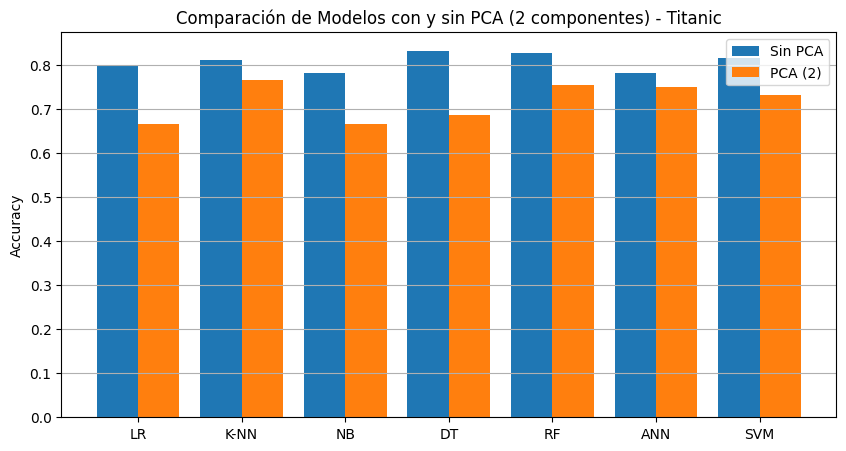

In [14]:
# =========================================
# 3.10 COMPARACIÓN CON LOS RESULTADOS YA CALCULADOS
# =========================================

import numpy as np
import matplotlib.pyplot as plt

labels = [r[0] for r in resultados]

acc_no_pca = [r[1] for r in resultados]
acc_pca_2 = [r[3] for r in resultados]

x = np.arange(len(labels))

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, acc_no_pca, width=0.4, label="Sin PCA")
plt.bar(x + 0.2, acc_pca_2, width=0.4, label="PCA (2)")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos con y sin PCA (2 componentes) - Titanic")
plt.legend()
plt.grid(axis="y")
plt.show()


### 3.11 Tabla de Resultado

Se construye una tabla final con los resultados obtenidos de cada modelo de clasificación, tanto sin PCA como con PCA de 2 componentes. Esta tabla incluye la exactitud (accuracy) y el tamaño del modelo en kilobytes en ambos casos, permitiendo comparar el rendimiento y la eficiencia de los modelos de forma resumida y estructurada. Finalmente, se imprime la tabla con todos los resultados finales.

In [15]:
# =========================================
# 3.11. TABLA FINAL DE RESULTADOS
# =========================================

df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "ACC",
        "KB (sin PCA)",
        "ACC PCA(2)",
        "KB PCA(2)"
    ]
)

print("\nRESULTADOS FINALES\n")
print(df_resultados)



RESULTADOS FINALES

  Modelo    ACC  KB (sin PCA)  ACC PCA(2)  KB PCA(2)
0     LR  0.799           0.9       0.665        0.9
1   K-NN  0.810          94.8       0.765       36.7
2     NB  0.782           1.0       0.665        0.8
3     DT  0.832          25.2       0.687       27.9
4     RF  0.827        2330.3       0.754     2138.4
5    ANN  0.782          32.7       0.749       14.2
6    SVM  0.816          25.6       0.732       15.1


## 4. Análisis de Resultados y Comparación por Modelo

A continuación se presenta un análisis comparativo de los modelos evaluados **con y sin PCA (2 componentes)**, considerando dos criterios clave:

- **Rendimiento predictivo** → Accuracy (ACC)
- **Costo computacional** → Tamaño del modelo en KB (KB)


### 4.1 Interpretación General

El uso de **PCA con 2 componentes** introduce una **reducción de dimensionalidad** (de 7 features originales a 2 componentes), lo que tiene dos efectos principales:

1. **Reducción del tamaño del modelo** en algunos algoritmos (especialmente K-NN, RF, ANN y SVM), aunque menos pronunciada que en el dataset de cáncer (30 → 2), ya que el Titanic parte de muchas menos variables.
2. **Disminución notable de la exactitud** en la mayoría de los modelos, más marcada que en el dataset de cáncer de mama. Esto confirma la hipótesis: con solo 7 features originales, comprimir a 2 componentes pierde una fracción mayor de la información útil que en un dataset con 30 variables.

### 4.2 Comparación Modelo por Modelo

| Modelo | ACC sin PCA | KB sin PCA | ACC PCA (2) | KB PCA (2) | Análisis del impacto de PCA |
|------|-------------|------------|-------------|------------|-----------------------------|
| LR   | 0.799 | 0.9    | 0.665 | 0.9    | Caída fuerte de precisión (~13 puntos), sin ganancia en tamaño |
| K-NN | 0.810 | 94.8   | 0.765 | 36.7   | Caída moderada de ACC con buena reducción de tamaño (~61%) |
| NB   | 0.782 | 1.0    | 0.665 | 0.8    | Fuerte caída de precisión, mínima mejora en tamaño |
| DT   | 0.832 | 25.3   | 0.687 | 27.9   | Fuerte caída de precisión y leve aumento de tamaño — PCA perjudica claramente |
| RF   | 0.827 | 2330.3 | 0.754 | 2138.5 | Caída de precisión con reducción de tamaño marginal |
| ANN  | 0.782 | 35.3   | 0.749 | 16.7   | Caída leve de precisión con buena reducción de tamaño (~53%) |
| SVM  | 0.816 | 25.6   | 0.732 | 15.0   | Caída moderada de precisión con reducción de tamaño (~41%) |

### 4.3 Comparación con el comportamiento en Cáncer de Mama

A diferencia del dataset de cáncer de mama, donde la caída de accuracy al aplicar PCA era leve (entre 2 y 4 puntos porcentuales en la mayoría de los modelos), en el Titanic la caída es mucho más pronunciada (hasta 13-14 puntos porcentuales en LR y NB). Esto confirma la hipótesis planteada: al partir de solo 7 variables originales, reducir a 2 componentes principales descarta una proporción mucho mayor de la información discriminativa disponible, ya que cada una de las 7 variables originales (especialmente Sex y Pclass) aporta señal relevante de forma relativamente independiente.

### 5. K-MEANS (K=2 vs K=3)

Se aplica el algoritmo K-Means sobre el dataset de Titanic (previamente estandarizado y reducido con PCA para fines de visualización), entrenando dos configuraciones: K=2 y K=3. Para cada caso se calculan las métricas de evaluación interna (Silhouette Score, Calinski-Harabasz y Davies-Bouldin) con el fin de medir la cohesión y separación de los clústeres generados, y se comparan los resultados para determinar qué número de clústeres representa mejor la estructura del dataset.


 MÉTRICAS PARA K=2
Silhouette Score: 0.2766
Calinski-Harabasz: 206.33
Davies-Bouldin: 1.7402
Inercia: 5062.14

 MÉTRICAS PARA K=3
Silhouette Score: 0.3004
Calinski-Harabasz: 224.81
Davies-Bouldin: 1.4730
Inercia: 4140.55


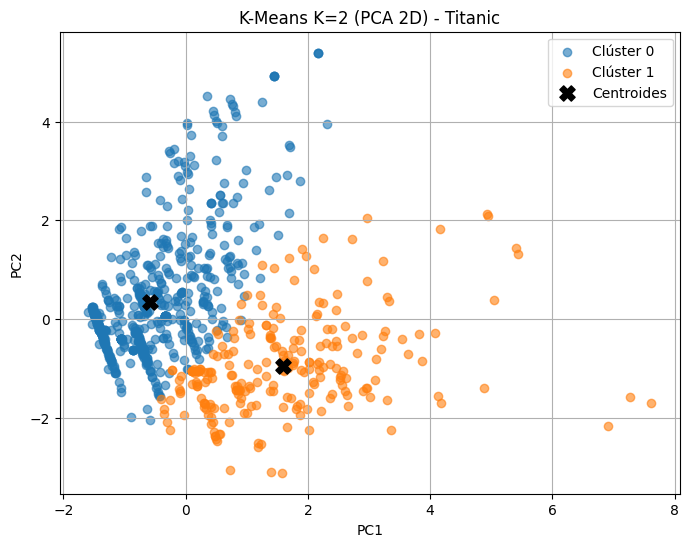

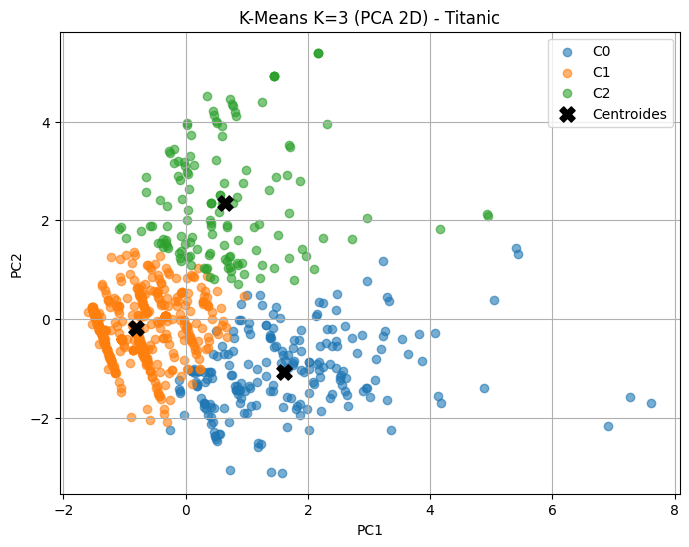


 COMPARACIÓN FINAL

K=2
Silhouette: 0.2766, CH: 206.33, DB: 1.7402, Inercia: 5062.14

K=3
Silhouette: 0.3004, CH: 224.81, DB: 1.4730, Inercia: 4140.55


['pca_titanic.pkl']

In [16]:
# =========================================
# K-MEANS EN TITANIC (K=2 vs K=3)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# 1. CARGA DE DATOS
# =========================================
df_cl = pd.read_csv("titanic_train.csv")
df_cl = df_cl.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df_cl["Age"] = df_cl["Age"].fillna(df_cl["Age"].median())
df_cl["Embarked"] = df_cl["Embarked"].fillna(df_cl["Embarked"].mode()[0])

le_sex_cl = LabelEncoder()
df_cl["Sex"] = le_sex_cl.fit_transform(df_cl["Sex"])
le_emb_cl = LabelEncoder()
df_cl["Embarked"] = le_emb_cl.fit_transform(df_cl["Embarked"])

X_cl = df_cl.drop(columns=["Survived"]).values
y_cl = df_cl["Survived"].values

# =========================================
# 2. ESCALADO
# =========================================
scaler_cl = StandardScaler()
X_scaled_cl = scaler_cl.fit_transform(X_cl)

# =========================================
# 3. PCA (2 COMPONENTES PARA VISUALIZACIÓN)
# =========================================
pca_cl = PCA(n_components=2)
X_pca_cl = pca_cl.fit_transform(X_scaled_cl)

# =========================================
# 4. FUNCIÓN DE EVALUACIÓN
# =========================================
def evaluar_modelo(X, labels, modelo, nombre="K"):
    print(f"\n MÉTRICAS PARA {nombre}")

    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)
    iner = modelo.inertia_

    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")
    print(f"Inercia: {iner:.2f}")

    return sil, cal, dav, iner

# =========================================
# 5. K-MEANS K=2
# =========================================
k2 = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
labels2 = k2.fit_predict(X_scaled_cl)

sil2, cal2, dav2, iner2 = evaluar_modelo(X_scaled_cl, labels2, k2, "K=2")

# =========================================
# 6. K-MEANS K=3
# =========================================
k3 = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
labels3 = k3.fit_predict(X_scaled_cl)

sil3, cal3, dav3, iner3 = evaluar_modelo(X_scaled_cl, labels3, k3, "K=3")

# =========================================
# 7. VISUALIZACIÓN EN PCA (K=2)
# =========================================
centroides2 = pca_cl.transform(k2.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_cl[labels2 == 0, 0], X_pca_cl[labels2 == 0, 1], alpha=0.6, label="Clúster 0")
plt.scatter(X_pca_cl[labels2 == 1, 0], X_pca_cl[labels2 == 1, 1], alpha=0.6, label="Clúster 1")
plt.scatter(centroides2[:,0], centroides2[:,1], c="black", marker="X", s=120, label="Centroides")
plt.title("K-Means K=2 (PCA 2D) - Titanic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 8. VISUALIZACIÓN EN PCA (K=3)
# =========================================
centroides3 = pca_cl.transform(k3.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_cl[labels3 == 0, 0], X_pca_cl[labels3 == 0, 1], alpha=0.6, label="C0")
plt.scatter(X_pca_cl[labels3 == 1, 0], X_pca_cl[labels3 == 1, 1], alpha=0.6, label="C1")
plt.scatter(X_pca_cl[labels3 == 2, 0], X_pca_cl[labels3 == 2, 1], alpha=0.6, label="C2")
plt.scatter(centroides3[:,0], centroides3[:,1], c="black", marker="X", s=120, label="Centroides")
plt.title("K-Means K=3 (PCA 2D) - Titanic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 9. COMPARACIÓN FINAL
# =========================================
print("\n COMPARACIÓN FINAL")

print("\nK=2")
print(f"Silhouette: {sil2:.4f}, CH: {cal2:.2f}, DB: {dav2:.4f}, Inercia: {iner2:.2f}")

print("\nK=3")
print(f"Silhouette: {sil3:.4f}, CH: {cal3:.2f}, DB: {dav3:.4f}, Inercia: {iner3:.2f}")

# =========================================
# 10. GUARDAR MODELOS
# =========================================
joblib.dump(k2, "kmeans_titanic_k2.pkl")
joblib.dump(k3, "kmeans_titanic_k3.pkl")
joblib.dump(scaler_cl, "scaler_titanic.pkl")
joblib.dump(pca_cl, "pca_titanic.pkl")


## 5.1 Análisis de Resultados

### 5.2 Resumen de métricas obtenidas

Para K=2:  
Silhouette Score: 0.2766  
Calinski-Harabasz: 206.33  
Davies-Bouldin: 1.7402  
Inercia: 5062.14  

Para K=3:  
Silhouette Score: 0.3004  
Calinski-Harabasz: 224.81  
Davies-Bouldin: 1.4730  
Inercia: 4140.55  

### 5.3 Análisis de K=2

El modelo con K=2 obtiene un Silhouette Score de 0.2766, lo que indica una separación moderada pero relativamente débil entre los clústeres. Este valor sugiere que la estructura binaria no representa de forma óptima la organización natural del dataset del Titanic.

La inercia para K=2 es de 5062.14, lo que refleja una mayor dispersión interna de los clústeres. Esto indica que los puntos se encuentran más alejados de sus centroides, evidenciando una cohesión interna limitada en la partición obtenida.

Al comparar la distribución de los clústeres K=2 con la variable real Survived, no se observa una correspondencia estructural fuerte, lo que indica que el modelo no está capturando directamente la variable objetivo.

### 5.4 Análisis de K=3

El modelo con K=3 mejora todas las métricas respecto a K=2. El Silhouette Score aumenta a 0.3004, indicando una mejor separación entre clústeres. El Calinski-Harabasz sube a 224.81, lo que refleja una mejor relación entre dispersión inter-clúster e intra-clúster. El Davies-Bouldin disminuye a 1.4730, lo que indica clústeres más compactos y mejor definidos.

La inercia disminuye a 4140.55, lo que es esperable al aumentar el número de clústeres. Este comportamiento indica que los puntos están, en promedio, más cerca de sus centroides, generando una partición más ajustada del espacio.

Estos resultados sugieren que el dataset del Titanic presenta una estructura más adecuada para tres clústeres que para dos, probablemente influenciada por variables como Pclass.

### 5.5 Comparación entre K=2 y K=3

A diferencia del dataset de cáncer de mama, en el Titanic el modelo K=3 supera a K=2 en todas las métricas de evaluación interna (Silhouette, Calinski-Harabasz y Davies-Bouldin), además de presentar una menor inercia.

Esto indica que la estructura geométrica del dataset está mejor representada por tres clústeres, los cuales parecen estar influenciados por la variable Pclass y otras variables socioeconómicas del pasajero.

### 5.6 Conclusión

El modelo K=3 es el más adecuado para este conjunto de datos, ya que presenta mejor cohesión interna, mejor separación entre clústeres y menor inercia. Sin embargo, los clústeres obtenidos no representan directamente la variable Survived, sino una estructura subyacente del dataset dominada por la clase del pasajero y otras características asociadas al estatus socioeconómico

### 6. Gaussian Mixture Models (GMM)

Como complemento al agrupamiento realizado con K-Means, se implementa el algoritmo **Gaussian Mixture Model (GMM)**, un método de agrupamiento probabilístico que modela los datos como una combinación de distribuciones gaussianas (normales) multivariadas.

A diferencia de K-Means, que asigna cada punto a un único clúster de forma rígida (hard clustering) basándose en la distancia euclidiana al centroide más cercano, GMM realiza una asignación **probabilística (soft clustering)**: cada observación recibe una probabilidad de pertenecer a cada uno de los clústeres, y la asignación final corresponde al clúster con mayor probabilidad. Además, GMM permite que los clústeres tengan formas elípticas (covarianzas distintas), mientras que K-Means asume clústeres esféricos.

Se entrena GMM con 2 componentes (K=2, alineado con las clases sobrevivió/no sobrevivió) y con 3 componentes (K=3), replicando el mismo análisis comparativo realizado con K-Means, para luego contrastar ambos algoritmos en la sección de Conclusiones Generales.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# 1. CARGA DE DATOS
# =========================================
df_gmm = pd.read_csv("titanic_train.csv")
df_gmm = df_gmm.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df_gmm["Age"] = df_gmm["Age"].fillna(df_gmm["Age"].median())
df_gmm["Embarked"] = df_gmm["Embarked"].fillna(df_gmm["Embarked"].mode()[0])

le_sex_gmm = LabelEncoder()
df_gmm["Sex"] = le_sex_gmm.fit_transform(df_gmm["Sex"])
le_emb_gmm = LabelEncoder()
df_gmm["Embarked"] = le_emb_gmm.fit_transform(df_gmm["Embarked"])

X_gmm = df_gmm.drop(columns=["Survived"]).values
y_gmm = df_gmm["Survived"].values

# =========================================
# 2. ESCALADO
# =========================================
scaler_gmm = StandardScaler()
X_scaled_gmm = scaler_gmm.fit_transform(X_gmm)

# =========================================
# 3. PCA
# =========================================
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_scaled_gmm)

# =========================================
# 4. FUNCIÓN DE INERCIA (GMM APROXIMADA)
# =========================================
def calcular_inercia(X, labels):
    iner = 0
    for c in np.unique(labels):
        cluster = X[labels == c]
        centro = cluster.mean(axis=0)
        iner += np.sum((cluster - centro) ** 2)
    return iner

# =========================================
# 5. FUNCIÓN DE EVALUACIÓN
# =========================================
def evaluar_modelo(X, labels, modelo, nombre="K"):
    print(f"\n MÉTRICAS PARA {nombre}")

    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)
    iner = calcular_inercia(X, labels)

    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")
    print(f"Inercia: {iner:.2f}")

    return sil, cal, dav, iner

# =========================================
# 6. GMM K=2
# =========================================
gmm2 = GaussianMixture(n_components=2, covariance_type="full", random_state=42, n_init=10)
labels_gmm2 = gmm2.fit_predict(X_scaled_gmm)

sil_gmm2, cal_gmm2, dav_gmm2, iner_gmm2 = evaluar_modelo(
    X_scaled_gmm, labels_gmm2, gmm2, "GMM K=2"
)

# =========================================
# 7. GMM K=3
# =========================================
gmm3 = GaussianMixture(n_components=3, covariance_type="full", random_state=42, n_init=10)
labels_gmm3 = gmm3.fit_predict(X_scaled_gmm)

sil_gmm3, cal_gmm3, dav_gmm3, iner_gmm3 = evaluar_modelo(
    X_scaled_gmm, labels_gmm3, gmm3, "GMM K=3"
)

# =========================================
# 8. COMPARACIÓN FINAL
# =========================================
print("\n COMPARACIÓN FINAL GMM")

print("\nGMM K=2")
print(f"Silhouette: {sil_gmm2:.4f}, CH: {cal_gmm2:.2f}, DB: {dav_gmm2:.4f}, Inercia: {iner_gmm2:.2f}")

print("\nGMM K=3")
print(f"Silhouette: {sil_gmm3:.4f}, CH: {cal_gmm3:.2f}, DB: {dav_gmm3:.4f}, Inercia: {iner_gmm3:.2f}")

# =========================================
# 9. GUARDAR MODELOS
# =========================================
joblib.dump(gmm2, "gmm_titanic_k2.pkl")
joblib.dump(gmm3, "gmm_titanic_k3.pkl")



 MÉTRICAS PARA GMM K=2
Silhouette Score: 0.2645
Calinski-Harabasz: 168.75
Davies-Bouldin: 2.1426
Inercia: 5241.99

 MÉTRICAS PARA GMM K=3
Silhouette Score: 0.2564
Calinski-Harabasz: 189.65
Davies-Bouldin: 1.7298
Inercia: 4370.26

 COMPARACIÓN FINAL GMM

GMM K=2
Silhouette: 0.2645, CH: 168.75, DB: 2.1426, Inercia: 5241.99

GMM K=3
Silhouette: 0.2564, CH: 189.65, DB: 1.7298, Inercia: 4370.26


['gmm_titanic_k3.pkl']

### 7. Comparacion K-MEANS VS GMM

In [18]:
import pandas as pd
# Resultados previamente obtenidos de K-Means y GMM
resultados = {
    "Modelo": ["K-Means (2)", "K-Means (3)", "GMM (2)", "GMM (3)"],
    "Silhouette": [sil2, sil3, sil_gmm2, sil_gmm3],
    "Calinski-Harabasz": [cal2, cal3, cal_gmm2, cal_gmm3],
    "Davies-Bouldin": [dav2, dav3, dav_gmm2, dav_gmm3],
    "Inercia": [iner2, iner3, iner_gmm2, iner_gmm3]
}

df_comparacion = pd.DataFrame(resultados)

print("\n TABLA COMPARATIVA DE MODELOS")
print(df_comparacion)


 TABLA COMPARATIVA DE MODELOS
        Modelo  Silhouette  Calinski-Harabasz  Davies-Bouldin      Inercia
0  K-Means (2)    0.276558         206.325582        1.740158  5062.141422
1  K-Means (3)    0.300437         224.807519        1.472959  4140.545557
2      GMM (2)    0.264470         168.746561        2.142649  5241.986318
3      GMM (3)    0.256430         189.653027        1.729752  4370.259244


### 8 Análisis de Resultados

#### 8.2 Resumen de métricas obtenidas

Para GMM K=2:  
Silhouette Score: 0.2645  
Calinski-Harabasz: 168.75  
Davies-Bouldin: 2.1426  
Inercia: 5241.99  

Para GMM K=3:  
Silhouette Score: 0.2564  
Calinski-Harabasz: 189.65  
Davies-Bouldin: 1.7298  
Inercia: 4370.26  

#### 8.3 Análisis de GMM K=2

GMM con 2 componentes obtiene un Silhouette Score de 0.2645, inferior al obtenido con K-Means K=2 (0.2766) y también inferior al observado en cáncer de mama (0.3145). Este valor indica una separación débil entre clústeres y una estructura poco definida en el espacio de variables del Titanic.

La inercia de 5241.99 es la más alta entre los modelos GMM evaluados, lo que indica una mayor dispersión interna de los clústeres. Esto sugiere que los puntos están más alejados de sus centros de masa, reflejando una cohesión interna baja y una partición menos eficiente del espacio.

El Davies-Bouldin de 2.1426 es el peor valor de todos los modelos, lo que confirma un alto grado de solapamiento entre clústeres. En conjunto, GMM K=2 no logra capturar una estructura clara en los datos.

#### 8.4 Análisis de GMM K=3

Con K=3, el Silhouette Score disminuye ligeramente a 0.2564, lo que indica una separación aún débil entre clústeres. Sin embargo, el Calinski-Harabasz mejora a 189.65 y el Davies-Bouldin mejora a 1.7298, lo que sugiere una mejor relación entre cohesión y separación en comparación con K=2.

La inercia disminuye a 4370.26, lo cual es consistente con un mayor número de clústeres. Esto indica que los puntos están, en promedio, más cerca de sus respectivos centros, generando una partición más ajustada del espacio.

El comportamiento mixto de las métricas refleja que GMM K=3 mejora parcialmente la estructura encontrada por GMM K=2, pero sin llegar a una separación claramente óptima.

#### 8.5 Comparación entre GMM K=2 y GMM K=3

En conjunto, GMM K=3 ofrece mejores resultados que GMM K=2 en Calinski-Harabasz, Davies-Bouldin y en la reducción de inercia, aunque presenta un Silhouette ligeramente inferior. Esto sugiere que el modelo con tres componentes describe mejor la estructura geométrica del dataset del Titanic.

#### 8.6 Comparación entre K-Means y GMM en Titanic

| Métrica | K-Means K=2 | GMM K=2 | K-Means K=3 | GMM K=3 |
|---|---|---|---|---|
| Silhouette Score | 0.2766 | 0.2645 | 0.3004 | 0.2564 |
| Calinski-Harabasz | 206.33 | 168.75 | 224.81 | 189.65 |
| Davies-Bouldin | 1.7402 | 2.1426 | 1.4729 | 1.7298 |
| Inercia | 5062.14 | 5241.99 | 4140.55 | 4370.26 |

En el Titanic, K-Means supera consistentemente a GMM en todas las métricas, incluida la inercia. Esto sugiere que la estructura de los datos es más compatible con clústeres esféricos que con distribuciones gaussianas elípticas, lo que favorece el supuesto de K-Means.

GMM, aunque más flexible teóricamente, no logra mejorar el rendimiento en este dataset, probablemente debido a la mezcla de variables categóricas codificadas y numéricas escaladas, lo que dificulta el ajuste de covarianzas efectivas.

En comparación con el dataset de cáncer de mama, se observa nuevamente que la estructura óptima de clustering depende fuertemente del dominio del problema, y no puede asumirse de forma generalizada.

## 9. Conclusiones Generales

**Sobre PCA y clasificación supervisada (Fase I):**
- Los modelos con **mayor exactitud sin PCA** son **Árbol de Decisión (DT, 0.832)** y **Random Forest (RF, 0.827)**, seguidos de SVM (0.816) y K-NN (0.810).
- **K-NN, ANN y SVM** son los modelos que **mejor mantienen su precisión relativa** al aplicar PCA, mientras que **LR, NB y DT** sufren las caídas más fuertes (hasta 13-14 puntos porcentuales).
- A diferencia del dataset de cáncer, donde Random Forest empeoraba tanto en precisión como en tamaño, en Titanic RF mantiene un tamaño similar pero sí pierde precisión de forma notable.
- En este dataset, **PCA con 2 componentes no resulta tan ventajoso como en cáncer de mama**: la pérdida de accuracy es proporcionalmente mayor frente a la ganancia en eficiencia, dado que el dataset original ya es de baja dimensionalidad (7 variables) y cada variable aporta información relevante.

**Sobre el agrupamiento no supervisado (Fase II — K-Means y GMM):**
- A diferencia del dataset de cáncer de mama, donde K=2 era claramente la mejor opción por la naturaleza binaria del problema, en el Titanic **K=3 resulta más adecuado según las métricas internas de clustering**, tanto en K-Means como (parcialmente) en GMM. Esto evidencia que la estructura geométrica natural de los datos está más alineada con las 3 clases del pasaje (Pclass) que con la variable de supervivencia (Survived).
- Al comparar ambos algoritmos, **K-Means supera consistentemente a GMM** en las tres métricas internas evaluadas (Silhouette, Calinski-Harabasz y Davies-Bouldin), tanto para K=2 como para K=3, contrario a lo que su menor flexibilidad teórica podría sugerir.
- Esto resalta una lección estadística importante: el agrupamiento no supervisado revela patrones intrínsecos en los datos, que no necesariamente coinciden con la variable objetivo de interés (Survived) para un problema de clasificación supervisada. Para predecir supervivencia, los algoritmos supervisados (Fase I) siguen siendo el enfoque correcto; el clustering aporta, en cambio, una visión exploratoria complementaria sobre la estructura subyacente del dataset.

**Conclusión integradora:**
A diferencia del dataset de cáncer de mama —donde tanto PCA como el clustering reflejaban consistentemente la estructura binaria del problema (maligno/benigno)—, en el Titanic se observa una disociación entre el problema de clasificación (Survived, binario) y la estructura geométrica dominante de los datos (asociada a Pclass, con 3 niveles). Esto demuestra que la efectividad de PCA y del clustering no supervisado depende fuertemente de cuántas variables originales existen y de qué tan fuertemente correlacionadas están con la variable objetivo, y que un modelo más flexible (como GMM) no garantiza mejores resultados si sus supuestos no se ajustan bien a la verdadera distribución de los datos.


## 10. Aplicacion en el campo laboral

### Dario Herrera
Como profesional del sector de pagos electrónicos, una posible evolución de este proyecto sería fortalecer los sistemas de detección de fraude mediante algoritmos de aprendizaje automático. Se podrían utilizar Árboles de Decisión para generar reglas de riesgo explicables, SVM para mejorar la clasificación de transacciones fraudulentas y Redes Neuronales para detectar patrones complejos en tiempo real. Además, PCA permitiría reducir la dimensionalidad de los datos para optimizar el rendimiento de los modelos, mientras que K-Means y GMM facilitarían el agrupamiento de clientes, comercios o transacciones con comportamientos similares, ayudando a identificar anomalías y posibles fraudes. Esto contribuiría a mejorar el Fraud Scoring, reducir falsos positivos y reforzar la seguridad sin afectar la experiencia del cliente.

### Santiago Guallichico

### Robinson Chiluisa

En un data center, PCA, K-Means y GMM se utilizan para analizar grandes volúmenes de datos generados por servidores, sistemas de enfriamiento, energía y sensores ambientales.
El PCA se usa para reducir la cantidad de variables del sistema sin perder información importante. Esto permite simplificar el análisis de datos como temperatura, consumo eléctrico y carga de servidores, facilitando la detección de patrones y comportamientos anómalos.
K-Means y GMM se utilizan para agrupar equipos o estados operativos similares. Por ejemplo, permiten clasificar servidores según su nivel de carga, identificar zonas con alta temperatura o agrupar patrones de consumo energético; GMM resulta especialmente útil cuando los estados operativos no tienen fronteras claras y se solapan parcialmente.
La combinación de PCA, K-Means y GMM ayuda a simplificar la información del data center y a identificar patrones útiles para mejorar la eficiencia, detectar anomalías y optimizar el uso de recursos.